# Problem 1

In [ ]:
### IMPORTS 

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display 
plt.style.use('default')

from sklearn.base import clone  # Import clone so each fit uses a fresh estimator.
from sklearn.linear_model import LinearRegression  # Import ordinary least-squares regression.
from sklearn.metrics import mean_squared_error  # Import the explicit regression error metric.
from sklearn.model_selection import train_test_split  # Import train/test splitting.
from sklearn.model_selection import KFold, LeaveOneOut, cross_val_predict, cross_val_score  # Import k-fold, LOOCV, and scoring helper.
from sklearn.pipeline import make_pipeline  # Import pipeline construction for basis expansion plus regression.
from sklearn.preprocessing import PolynomialFeatures  # Import polynomial feature expansion.

In [ ]:
### GLOBAL VARS 

RANDOM_SEED = 123

## Gerenate Data

In [ ]:
def make_sine_regression_data(n=100, noise=0.35, random_state=123):  # Generate a smooth nonlinear regression data set.
    rng = np.random.default_rng(random_state)  # Create a reproducible random-number generator.
    x = np.sort(rng.uniform(0.0, 3.0, size=n))  # Draw and sort x values for clean smoother plots.
    signal = 4.0 + np.sin(3.0 * x)  # Define a smooth nonlinear mean function.
    y = signal + rng.normal(0.0, noise, size=n)  # Add Gaussian noise around the smooth signal.
    X = x.reshape(-1, 1)  # Reshape x into a sklearn design matrix.
    dat = pd.DataFrame({'x': x, 'y': y, 'truth': signal})  # Store the observed and true curves.
    return X, y, dat  # Return sklearn arrays plus the data frame.

In [ ]:
def plot_regression_dat(dat, ax, title):  # Define a reusable regression plotting helper.
    order = np.argsort(dat['x'].to_numpy())  # Sort by x so the true curve draws correctly.
    ax.scatter(dat['x'], dat['y'], s=22, alpha=0.60, label='observed')  # Plot noisy observations.
    if 'truth' in dat.columns:  # Check whether the true signal is available.
        ax.plot(dat['x'].to_numpy()[order], dat['truth'].to_numpy()[order], color='red', linewidth=2, label='truth')  # Plot the true mean curve.
    ax.set_title(title)  # Add a short subplot title.
    ax.set_xlabel('x')  # Label the predictor axis.
    ax.set_ylabel('y')  # Label the response axis.
    ax.legend(fontsize=8)  # Show the legend using compact font.

In [ ]:
X, y, data = make_sine_regression_data(random_state = RANDOM_SEED)

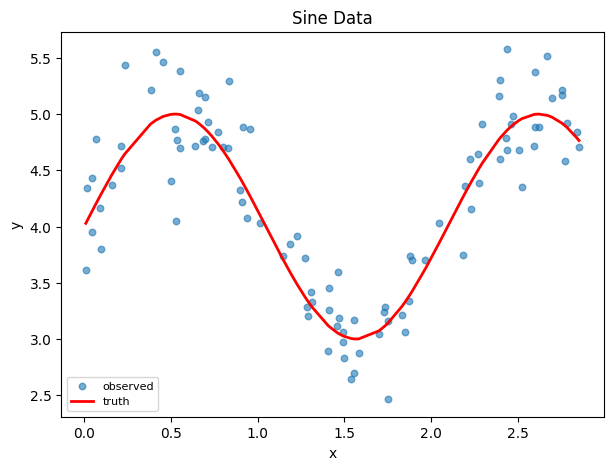

In [ ]:
fig, axes = plt.subplots(1, 1, figsize=(7, 5))  # Create a grid of regression plots.
# axes_flat = axes.ravel()  # Flatten the axes array for easy looping.
plot_regression_dat(data, axes, "Sine Data")